# SP500 Isolated Analysis
This notebook provides a detailed quantitative analysis of the S&P 500 without comparing it to other funds. It includes basic metrics, rolling statistics, distribution analysis, seasonality, and autocorrelation checks.

In [29]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, probplot
import yfinance as yf

sns.set_theme()

# Set start and end dates here
START_DATE = '1990-01-01'
END_DATE = '2026-08-01'

# Load data from yfinance
df = yf.download('^GSPC', start=START_DATE, end=END_DATE, interval='1mo', progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df_close = df['Close']['^GSPC']
else:
    df_close = df['Close']

# Calculate monthly returns
sp500 = df_close.pct_change().dropna()

# Make the index tz-naive to avoid issues
sp500.index = sp500.index.tz_localize(None)

print(f"Data Loaded: {len(sp500)} months of SP500 returns.")
sp500.head()

Data Loaded: 438 months of SP500 returns.


Date
1990-02-01    0.008539
1990-03-01    0.024255
1990-04-01   -0.026887
1990-05-01    0.091989
1990-06-01   -0.008886
Name: ^GSPC, dtype: float64

In [30]:
start_date = sp500.index.min()
end_date = sp500.index.max()
n_months = len(sp500)
time_elapsed = end_date - start_date
years_elapsed = time_elapsed.days / 365.25

print("--- Dataset Info ---")
print(f"Start Date: {start_date.date()}")
print(f"End Date:   {end_date.date()}")
print(f"Time Elapsed: {time_elapsed.days} days ({years_elapsed:.2f} years)")
print(f"Total Data Points: {n_months} months")

sp500_pos_months = (sp500 > 0).sum()
print("\n--- Positive Months (Hit Rate) ---")
print(f"SP500 Positive Months: {sp500_pos_months/n_months:.2%} ({sp500_pos_months}/{n_months})")

--- Dataset Info ---
Start Date: 1990-02-01
End Date:   2026-07-01
Time Elapsed: 13299 days (36.41 years)
Total Data Points: 438 months

--- Positive Months (Hit Rate) ---
SP500 Positive Months: 63.93% (280/438)


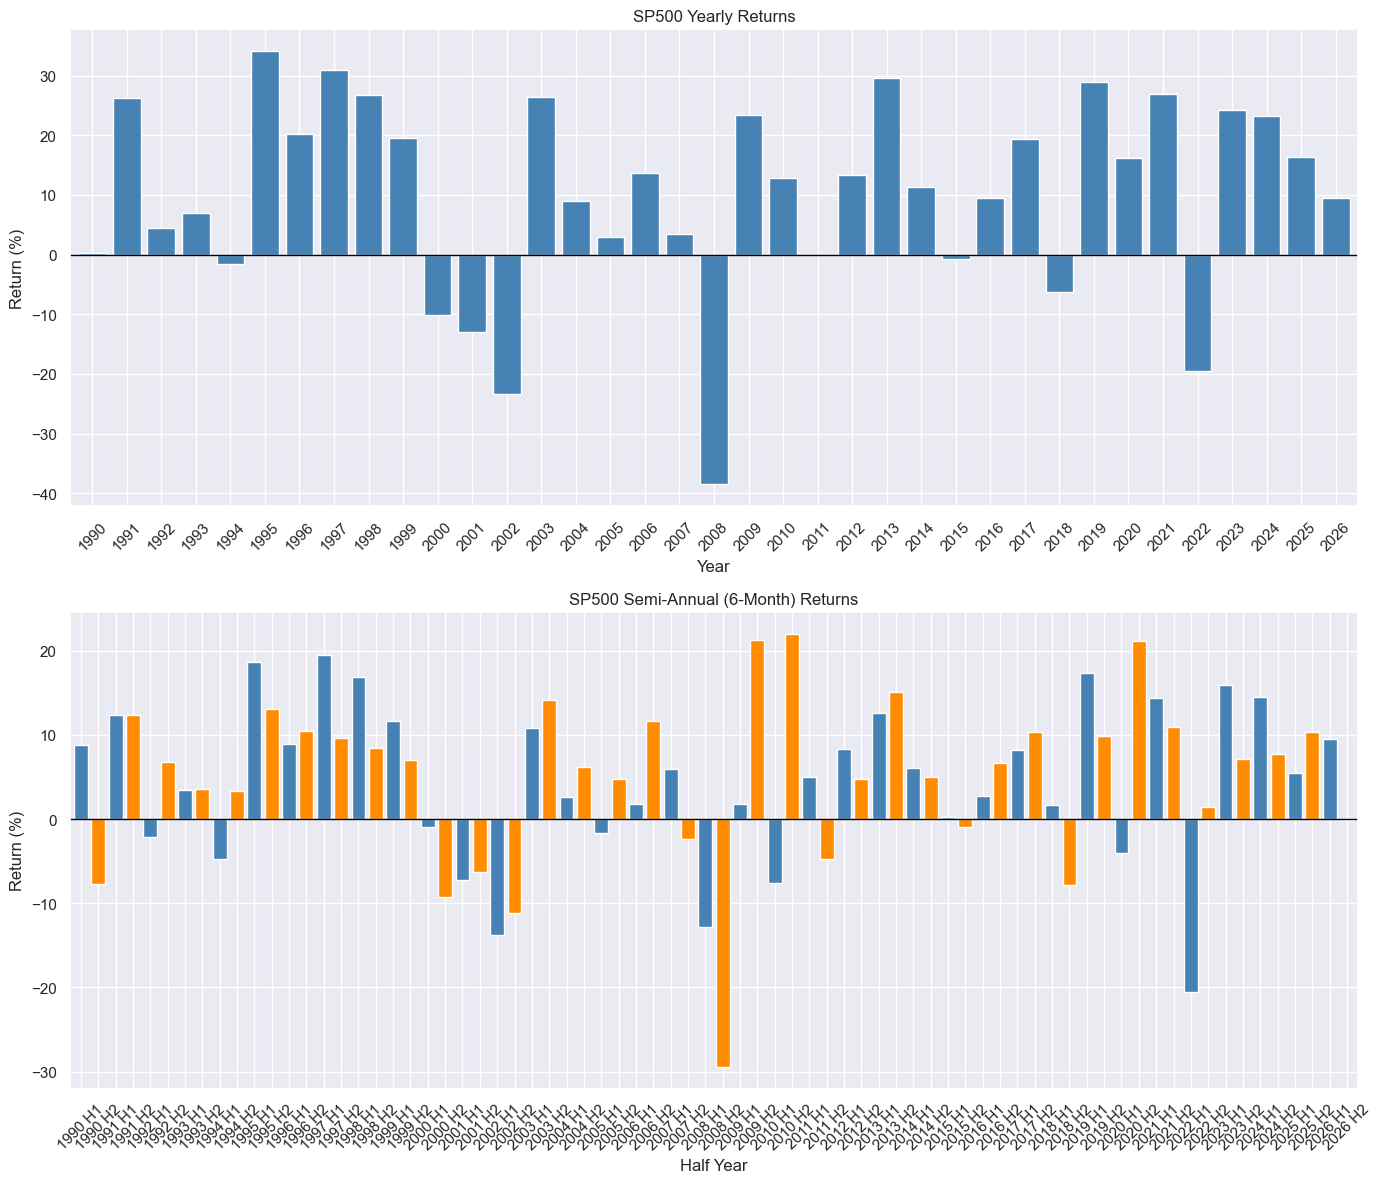

In [31]:
# Yearly Returns
yearly_returns = (1 + sp500).groupby(sp500.index.year).prod() - 1

# 6-Month Returns (First Half: Jan-Jun, Second Half: Jul-Dec)
half_year_grouper = sp500.index.map(lambda x: f"{x.year} H1" if x.month <= 6 else f"{x.year} H2")
semi_annual_returns = (1 + sp500).groupby(half_year_grouper).prod() - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot Yearly Returns
yearly_returns_pct = yearly_returns * 100
yearly_returns_pct.plot(kind='bar', ax=axes[0], width=0.8, color='steelblue')
axes[0].set_title('SP500 Yearly Returns')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Return (%)')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].tick_params(axis='x', rotation=45)

# Plot 6-Month Returns
semi_annual_returns_pct = semi_annual_returns * 100
colors = ['steelblue' if 'H1' in str(idx) else 'darkorange' for idx in semi_annual_returns_pct.index]
semi_annual_returns_pct.plot(kind='bar', ax=axes[1], width=0.8, color=colors)
axes[1].set_title('SP500 Semi-Annual (6-Month) Returns')
axes[1].set_xlabel('Half Year')
axes[1].set_ylabel('Return (%)')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
mean_ret = sp500.mean() * 12
vol = sp500.std() * np.sqrt(12)
sharpe = mean_ret / vol if vol != 0 else np.nan

# CAGR
cum_ret = (1 + sp500).prod()
n_years = n_months / 12
cagr = cum_ret**(1/n_years) - 1

# Max Drawdown
cum_wealth = (1 + sp500).cumprod()
peak = cum_wealth.cummax()
drawdown = (cum_wealth - peak) / peak
max_drawdown = drawdown.min()

# Calmar Ratio
calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

# Sortino Ratio (using 0% as risk-free rate)
downside_returns = sp500[sp500 < 0]
downside_vol = downside_returns.std() * np.sqrt(12)
sortino = mean_ret / downside_vol if downside_vol != 0 else np.nan

print(f"--- Trading Metrics (n={n_months} months) ---")
print(f"Annualized Mean Return: {mean_ret:.4f}")
print(f"Annualized Volatility:  {vol:.4f}")
print(f"Sharpe Ratio:           {sharpe:.4f}")
print(f"Sortino Ratio:          {sortino:.4f}")
print(f"CAGR:                   {cagr:.4f}")
print(f"Max Drawdown:           {max_drawdown:.4f}")
print(f"Calmar Ratio:           {calmar:.4f}")

--- Trading Metrics (n=438 months) ---
Annualized Mean Return: 0.0968
Annualized Volatility:  0.1470
Sharpe Ratio:           0.6585
Sortino Ratio:          0.9109
CAGR:                   0.0894
Max Drawdown:           -0.5256
Calmar Ratio:           0.1701


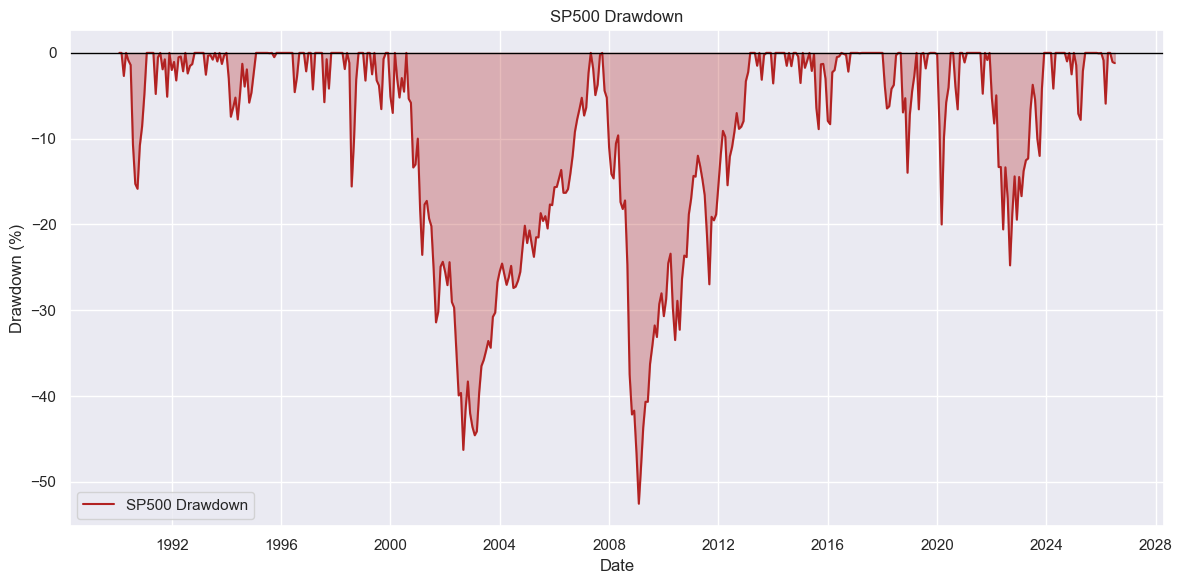

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(drawdown.index, drawdown * 100, label='SP500 Drawdown', color='firebrick')
plt.fill_between(drawdown.index, drawdown * 100, 0, color='firebrick', alpha=0.3)
plt.title('SP500 Drawdown')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.axhline(0, color='black', linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

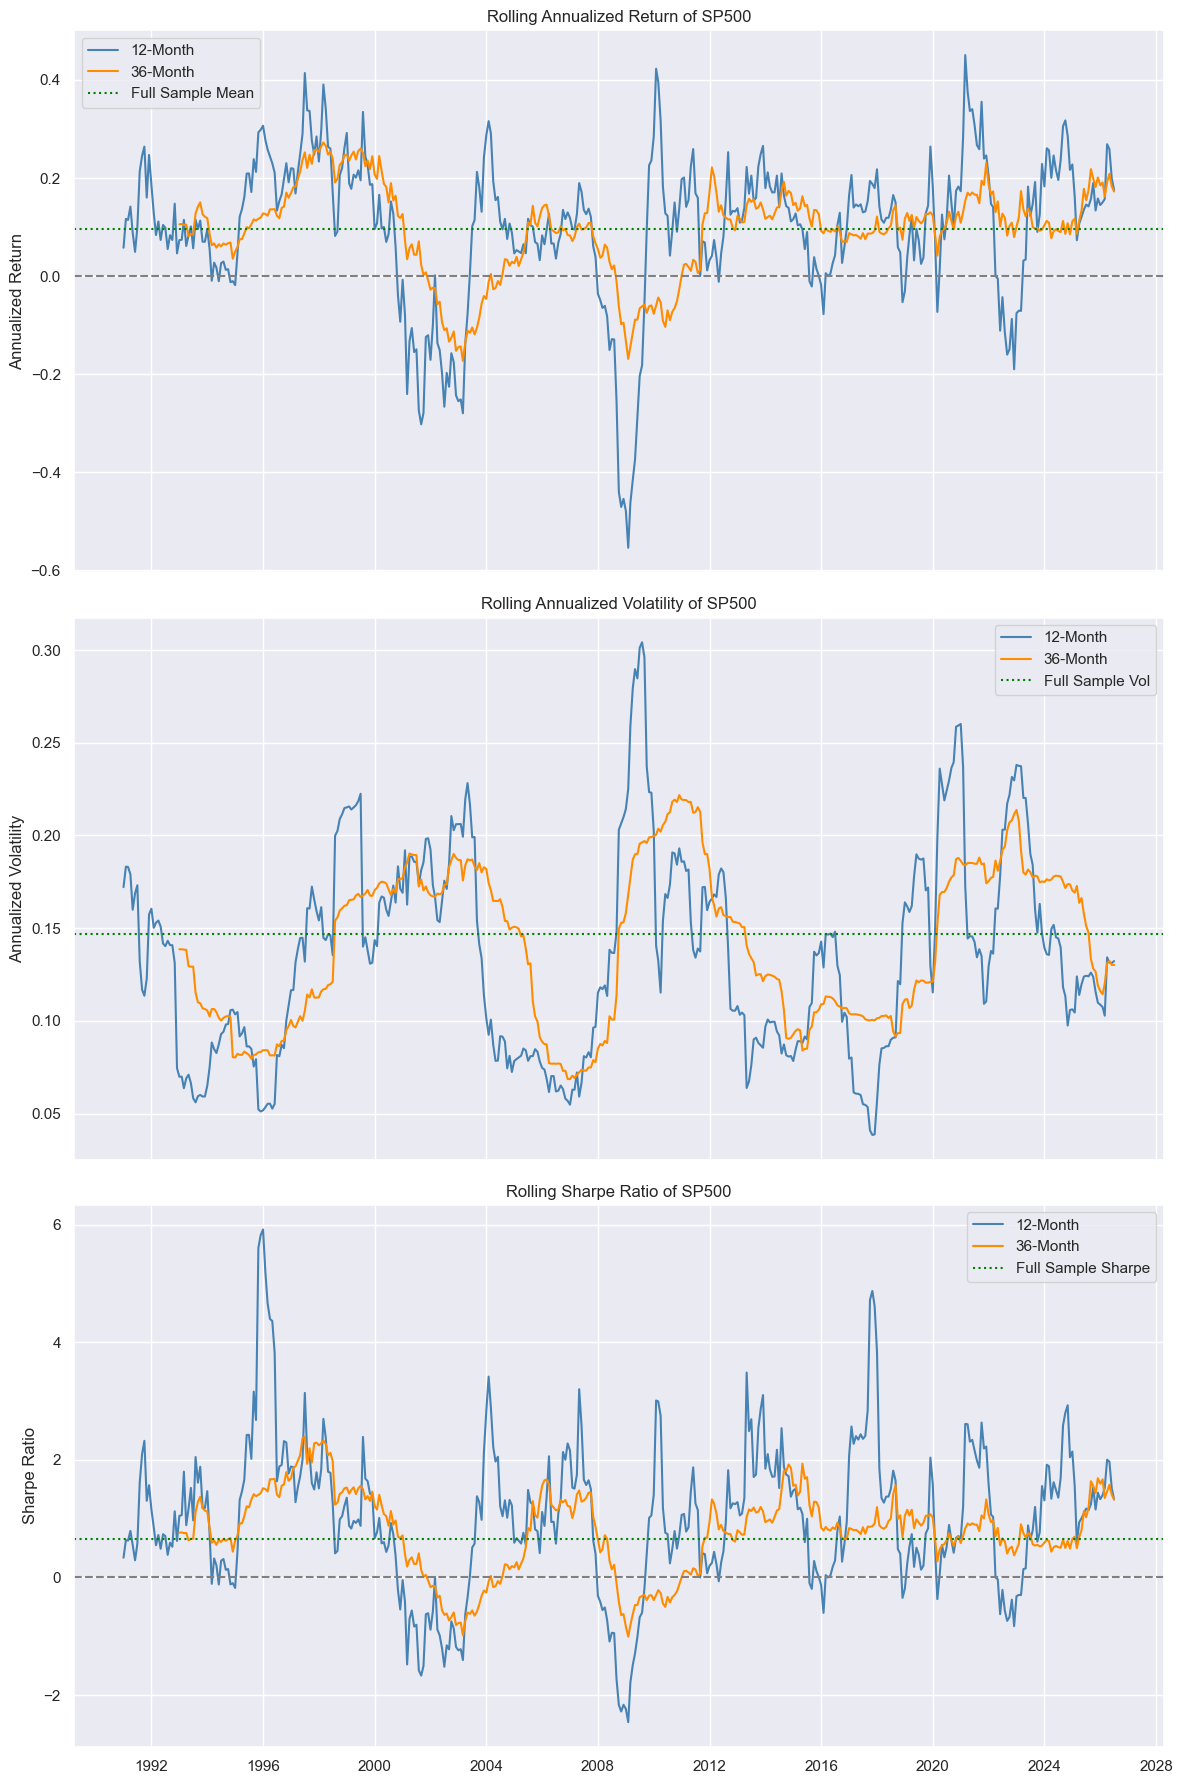

In [34]:
window_12 = 12
window_36 = 36

# Rolling mean multiplied by 12 for annualized representation
roll_mean_12 = sp500.rolling(window_12).mean() * 12
roll_mean_36 = sp500.rolling(window_36).mean() * 12

roll_vol_12 = sp500.rolling(window_12).std() * np.sqrt(12)
roll_vol_36 = sp500.rolling(window_36).std() * np.sqrt(12)

roll_sharpe_12 = roll_mean_12 / roll_vol_12
roll_sharpe_36 = roll_mean_36 / roll_vol_36

fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)

# Rolling Annualized Mean
axes[0].plot(roll_mean_12, label='12-Month', color='steelblue')
axes[0].plot(roll_mean_36, label='36-Month', color='darkorange')
axes[0].axhline(0, color='grey', linestyle='--')
axes[0].axhline(mean_ret, color='green', linestyle=':', label='Full Sample Mean')
axes[0].set_title('Rolling Annualized Return of SP500')
axes[0].legend()
axes[0].set_ylabel('Annualized Return')

# Rolling Annualized Volatility
axes[1].plot(roll_vol_12, label='12-Month', color='steelblue')
axes[1].plot(roll_vol_36, label='36-Month', color='darkorange')
axes[1].axhline(vol, color='green', linestyle=':', label='Full Sample Vol')
axes[1].set_title('Rolling Annualized Volatility of SP500')
axes[1].legend()
axes[1].set_ylabel('Annualized Volatility')

# Rolling Sharpe
axes[2].plot(roll_sharpe_12, label='12-Month', color='steelblue')
axes[2].plot(roll_sharpe_36, label='36-Month', color='darkorange')
axes[2].axhline(sharpe, color='green', linestyle=':', label='Full Sample Sharpe')
axes[2].axhline(0, color='grey', linestyle='--')
axes[2].set_title('Rolling Sharpe Ratio of SP500')
axes[2].legend()
axes[2].set_ylabel('Sharpe Ratio')

plt.tight_layout()
plt.show()

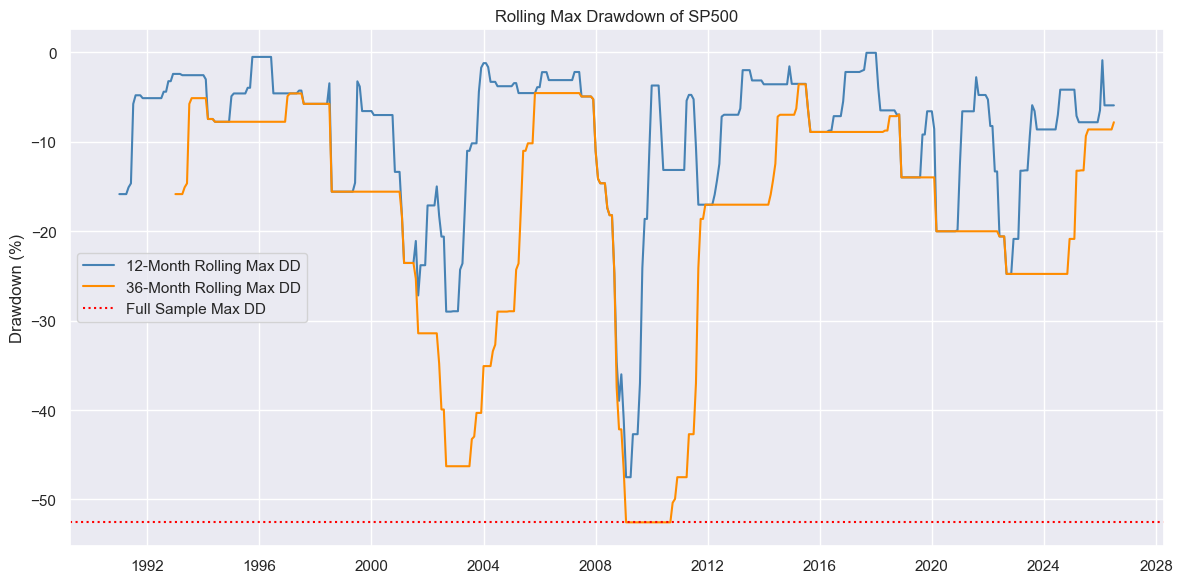

In [35]:
roll_mdd_12 = sp500.rolling(window_12).apply(lambda x: ((1 + x).cumprod() / (1 + x).cumprod().cummax() - 1).min(), raw=False)
roll_mdd_36 = sp500.rolling(window_36).apply(lambda x: ((1 + x).cumprod() / (1 + x).cumprod().cummax() - 1).min(), raw=False)

plt.figure(figsize=(12, 6))
plt.plot(roll_mdd_12 * 100, label='12-Month Rolling Max DD', color='steelblue')
plt.plot(roll_mdd_36 * 100, label='36-Month Rolling Max DD', color='darkorange')
plt.axhline(max_drawdown * 100, color='red', linestyle=':', label='Full Sample Max DD')
plt.title('Rolling Max Drawdown of SP500')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.tight_layout()
plt.show()

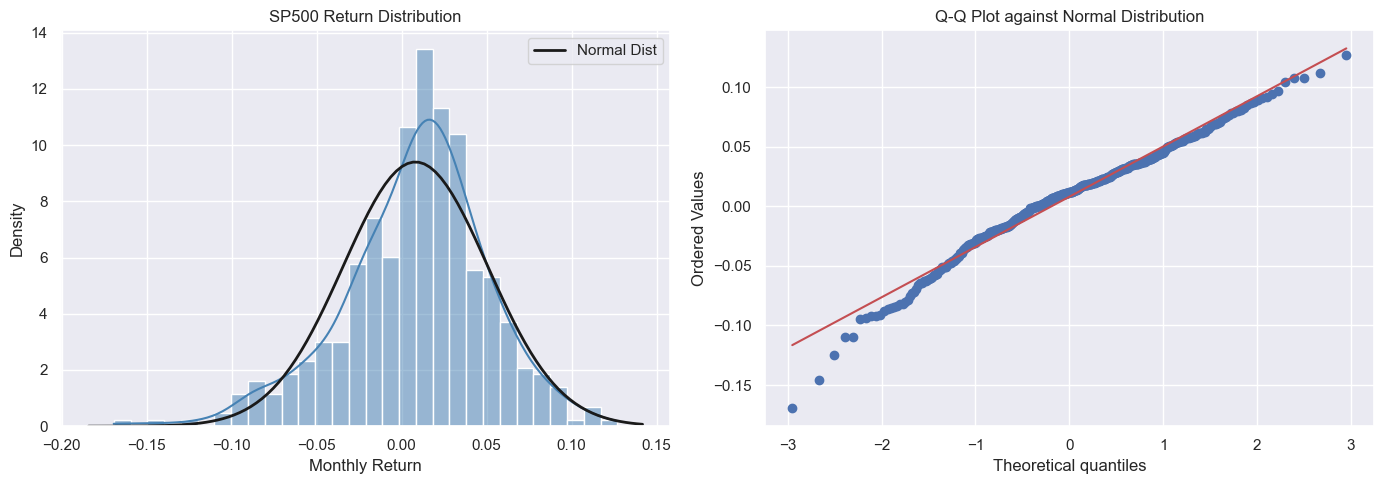

Skewness: -0.5281
Kurtosis: 1.0453

--- Tail Risk Metrics ---
Historical VaR (95%):  -6.9757%
Historical VaR (99%):  -10.4153%
Historical CVaR (95%): -9.5105%
Historical CVaR (99%): -13.2059%


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram and KDE
sns.histplot(sp500, kde=True, ax=axes[0], color='steelblue', stat='density', bins=30)
# Overlay Normal distribution
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, sp500.mean(), sp500.std())
axes[0].plot(x, p, 'k', linewidth=2, label='Normal Dist')
axes[0].set_title('SP500 Return Distribution')
axes[0].set_xlabel('Monthly Return')
axes[0].legend()

# Q-Q Plot
probplot(sp500, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot against Normal Distribution')

plt.tight_layout()
plt.show()

# Skewness and Kurtosis
print(f"Skewness: {sp500.skew():.4f}")
print(f"Kurtosis: {sp500.kurtosis():.4f}")

# Value at Risk (VaR) & Conditional VaR (CVaR)
var_95 = sp500.quantile(0.05)
var_99 = sp500.quantile(0.01)

cvar_95 = sp500[sp500 <= var_95].mean()
cvar_99 = sp500[sp500 <= var_99].mean()

print(f"\n--- Tail Risk Metrics ---")
print(f"Historical VaR (95%):  {var_95:.4%}")
print(f"Historical VaR (99%):  {var_99:.4%}")
print(f"Historical CVaR (95%): {cvar_95:.4%}")
print(f"Historical CVaR (99%): {cvar_99:.4%}")

In [37]:
sp500_df = pd.DataFrame(sp500)
sp500_df['Month'] = sp500_df.index.month
sp500_df['MonthName'] = sp500_df.index.strftime('%b')

# Order the months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sp500_df['MonthName'] = pd.Categorical(sp500_df['MonthName'], categories=month_order, ordered=True)

plt.figure(figsize=(12, 6))
sns.boxplot(x='MonthName', y='sp500', data=sp500_df, color='steelblue')
plt.axhline(0, color='black', linestyle='--')
plt.title('SP500 Monthly Return Distribution (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Monthly Return')
plt.tight_layout()
plt.show()

# Monthly Win Rate
monthly_stats = sp500_df.groupby('MonthName', observed=False)['sp500'].agg(
    Mean=lambda x: x.mean() * 100, # as %
    WinRate=lambda x: (x > 0).mean() * 100 # as %
)
print("--- Monthly Stats (in %) ---")
print(monthly_stats.round(2))

ValueError: Could not interpret value `sp500` for `y`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

--- Autocorrelation Diagnostic (Ljung-Box) ---
      lb_stat  lb_pvalue    bp_stat  bp_pvalue
1    0.071864   0.788641   0.071191   0.789611
3    4.046129   0.256526   3.989375   0.262614
6    7.488187   0.278046   7.352985   0.289433
12  16.195738   0.182434  15.770922   0.201955


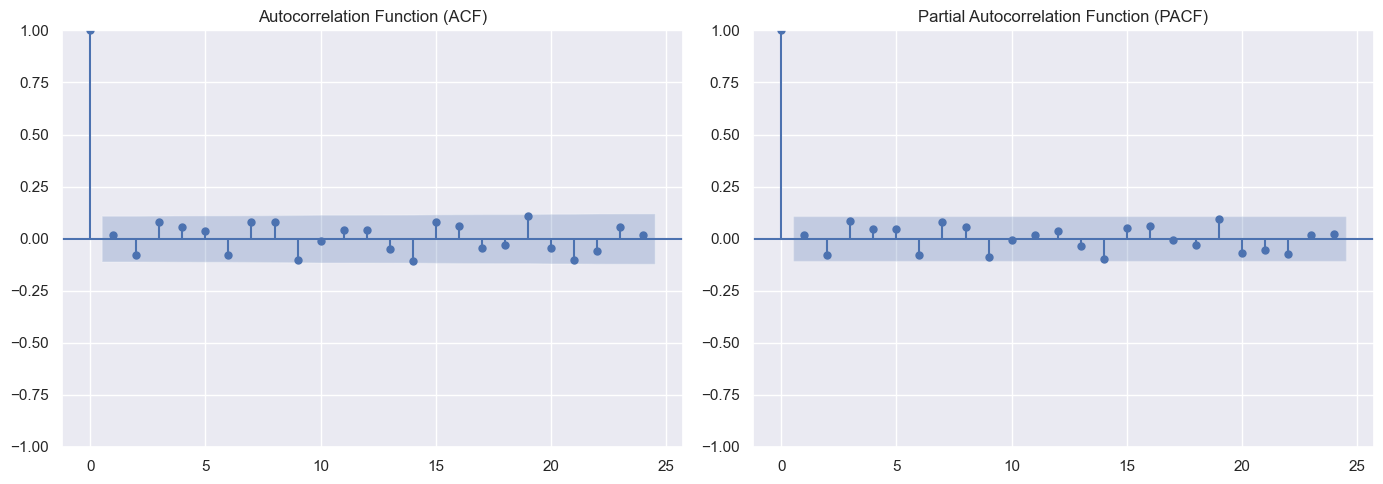

In [ ]:
import warnings
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

lags = min(24, len(sp500) // 2 - 1)
print("--- Autocorrelation Diagnostic (Ljung-Box) ---")
res = acorr_ljungbox(sp500, lags=[1, 3, 6, 12], boxpierce=True, return_df=True)
print(res)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(sp500, lags=lags, ax=axes[0], title='Autocorrelation Function (ACF)')
plot_pacf(sp500, lags=lags, ax=axes[1], title='Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()